In [1]:
#importing nessasary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# importing dataset
df = pd.read_csv("../dataset/cleaned_data.csv")

In [3]:
df.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,No,8,8,4,No
1,97,5.52,5.37,8,No,7,8,0,No
2,109,5.36,5.83,9,No,3,1,1,No
3,122,5.47,5.75,6,Yes,1,6,1,No
4,96,7.91,7.69,7,No,8,10,2,No


In [4]:
df.shape

(9751, 9)

<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\c'
C:\Users\HP\AppData\Local\Temp\ipykernel_25052\3488004643.py:5: SyntaxWarning: invalid escape sequence '\c'
  plt.savefig(f'..\charts\countplot_of_{col}.png')


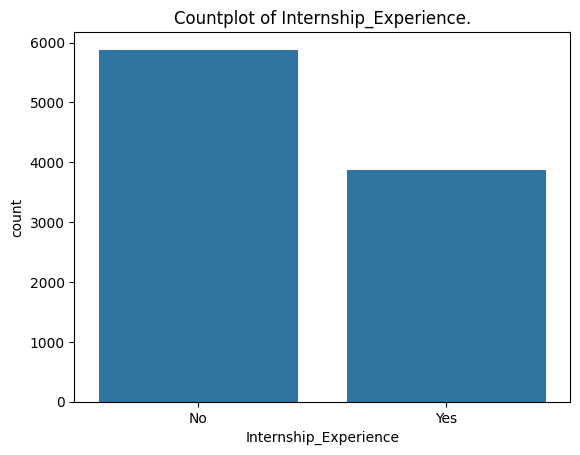

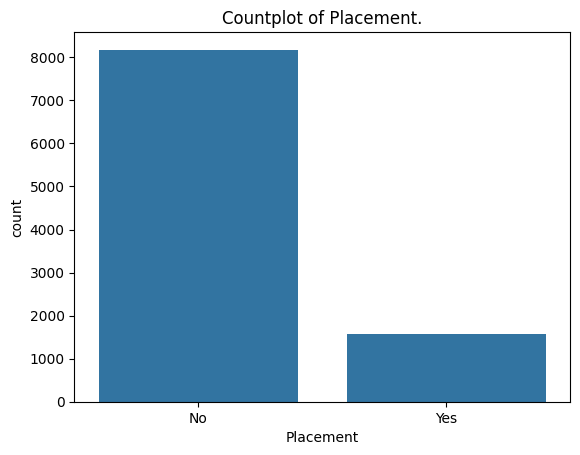

In [5]:
object_col = df.select_dtypes('object')
for col in object_col:
    plt.title(f"Countplot of {col}.")
    sns.countplot(x=col,data=df)
    plt.savefig(f'..\charts\countplot_of_{col}.png')
    plt.show()

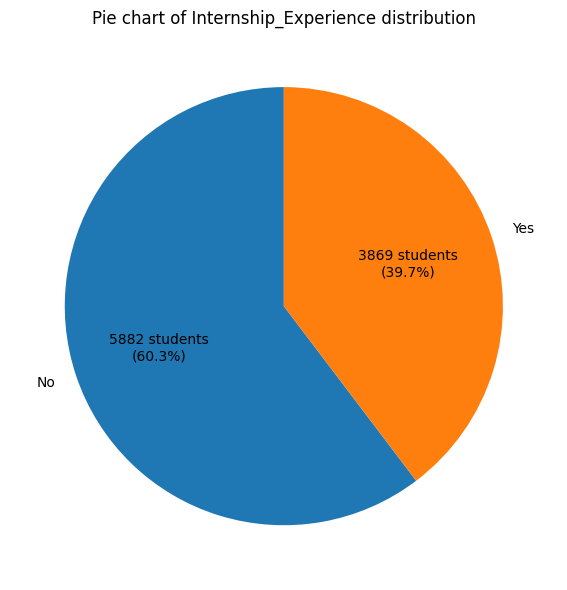

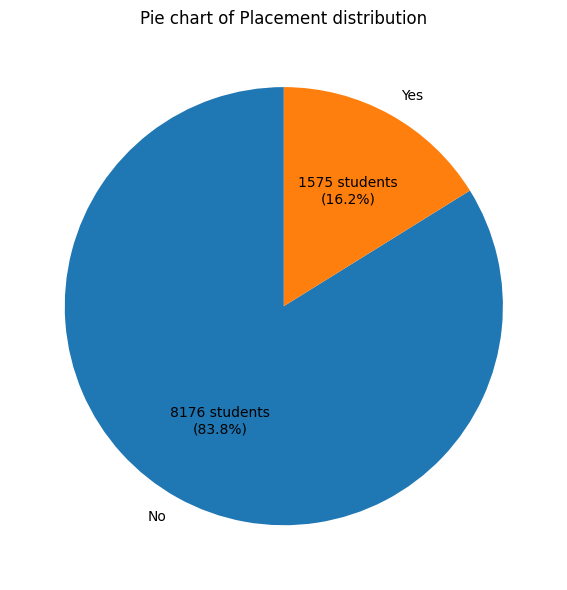

In [6]:
for col in object_col:
    plt.figure(figsize=(6,6))
    plt.title(f'Pie chart of {col} distribution')

    placement_distribution = df[col].value_counts()

    # Custom autopct function for showing count + percentage
    def autopct_func(pct):
        total = sum(placement_distribution)
        count = int(round(pct * total / 100.0))
        return f'{count} students\n({pct:.1f}%)'

    plt.pie(
        placement_distribution,
        labels=placement_distribution.index,
        autopct=autopct_func,
        startangle=90
    )

    plt.tight_layout()
    plt.savefig(f'../charts/pie_chart_of_{col}_distribution.png')
    plt.show()

### Distribution numerical values

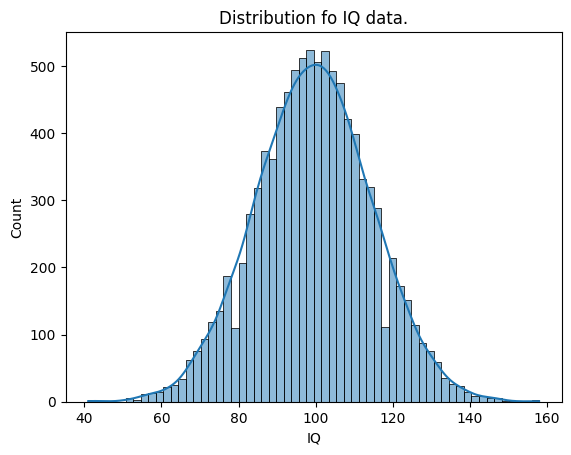

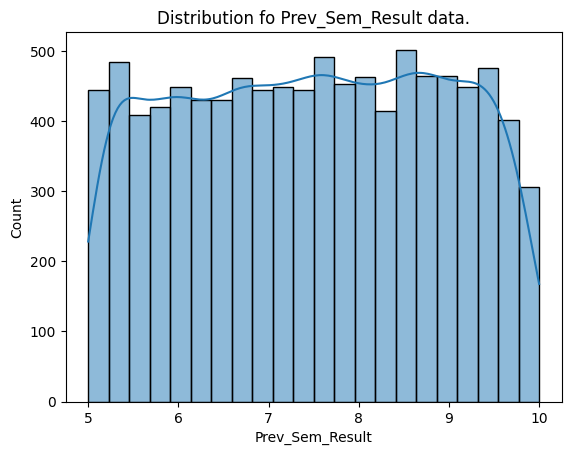

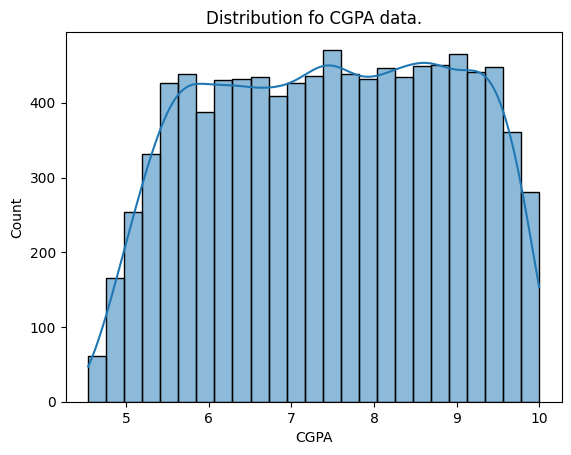

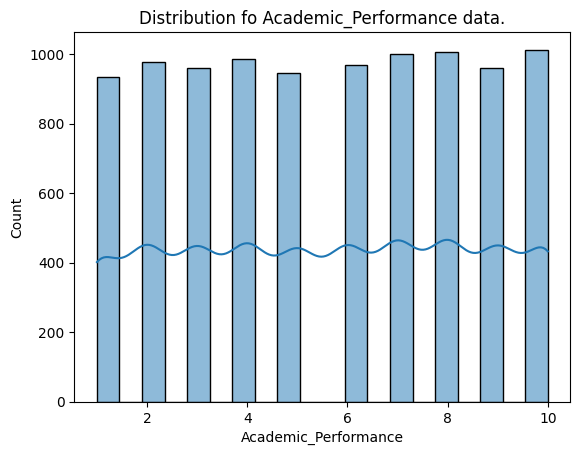

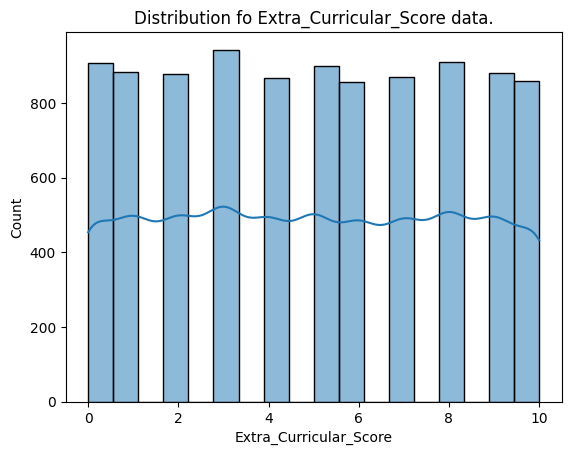

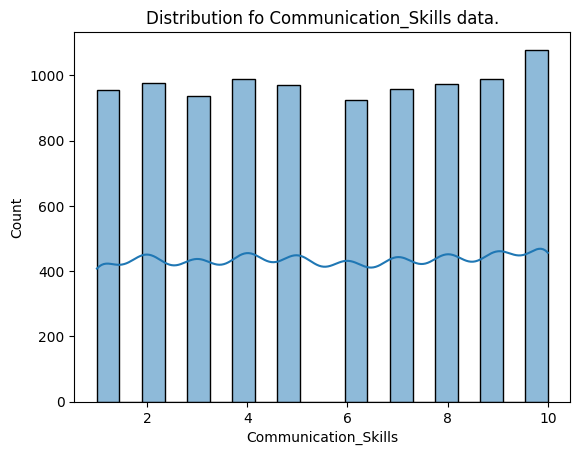

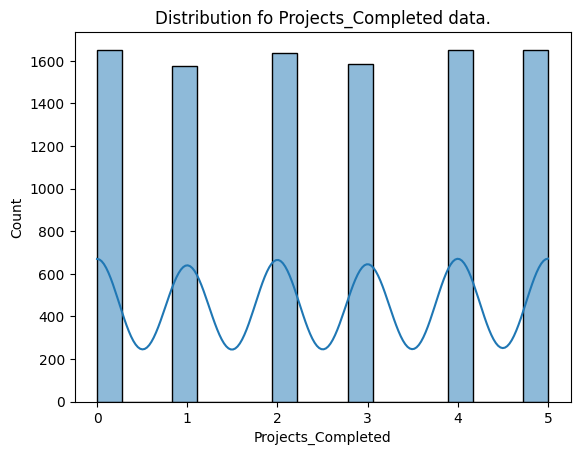

In [7]:
col_numeric = df.select_dtypes('number')
for col in col_numeric:
    plt.title(f'Distribution fo {col} data.')
    sns.histplot(x=col,data=df,kde=True)
    plt.savefig(f'../charts/distribution_of_{col}.png')
    plt.show()

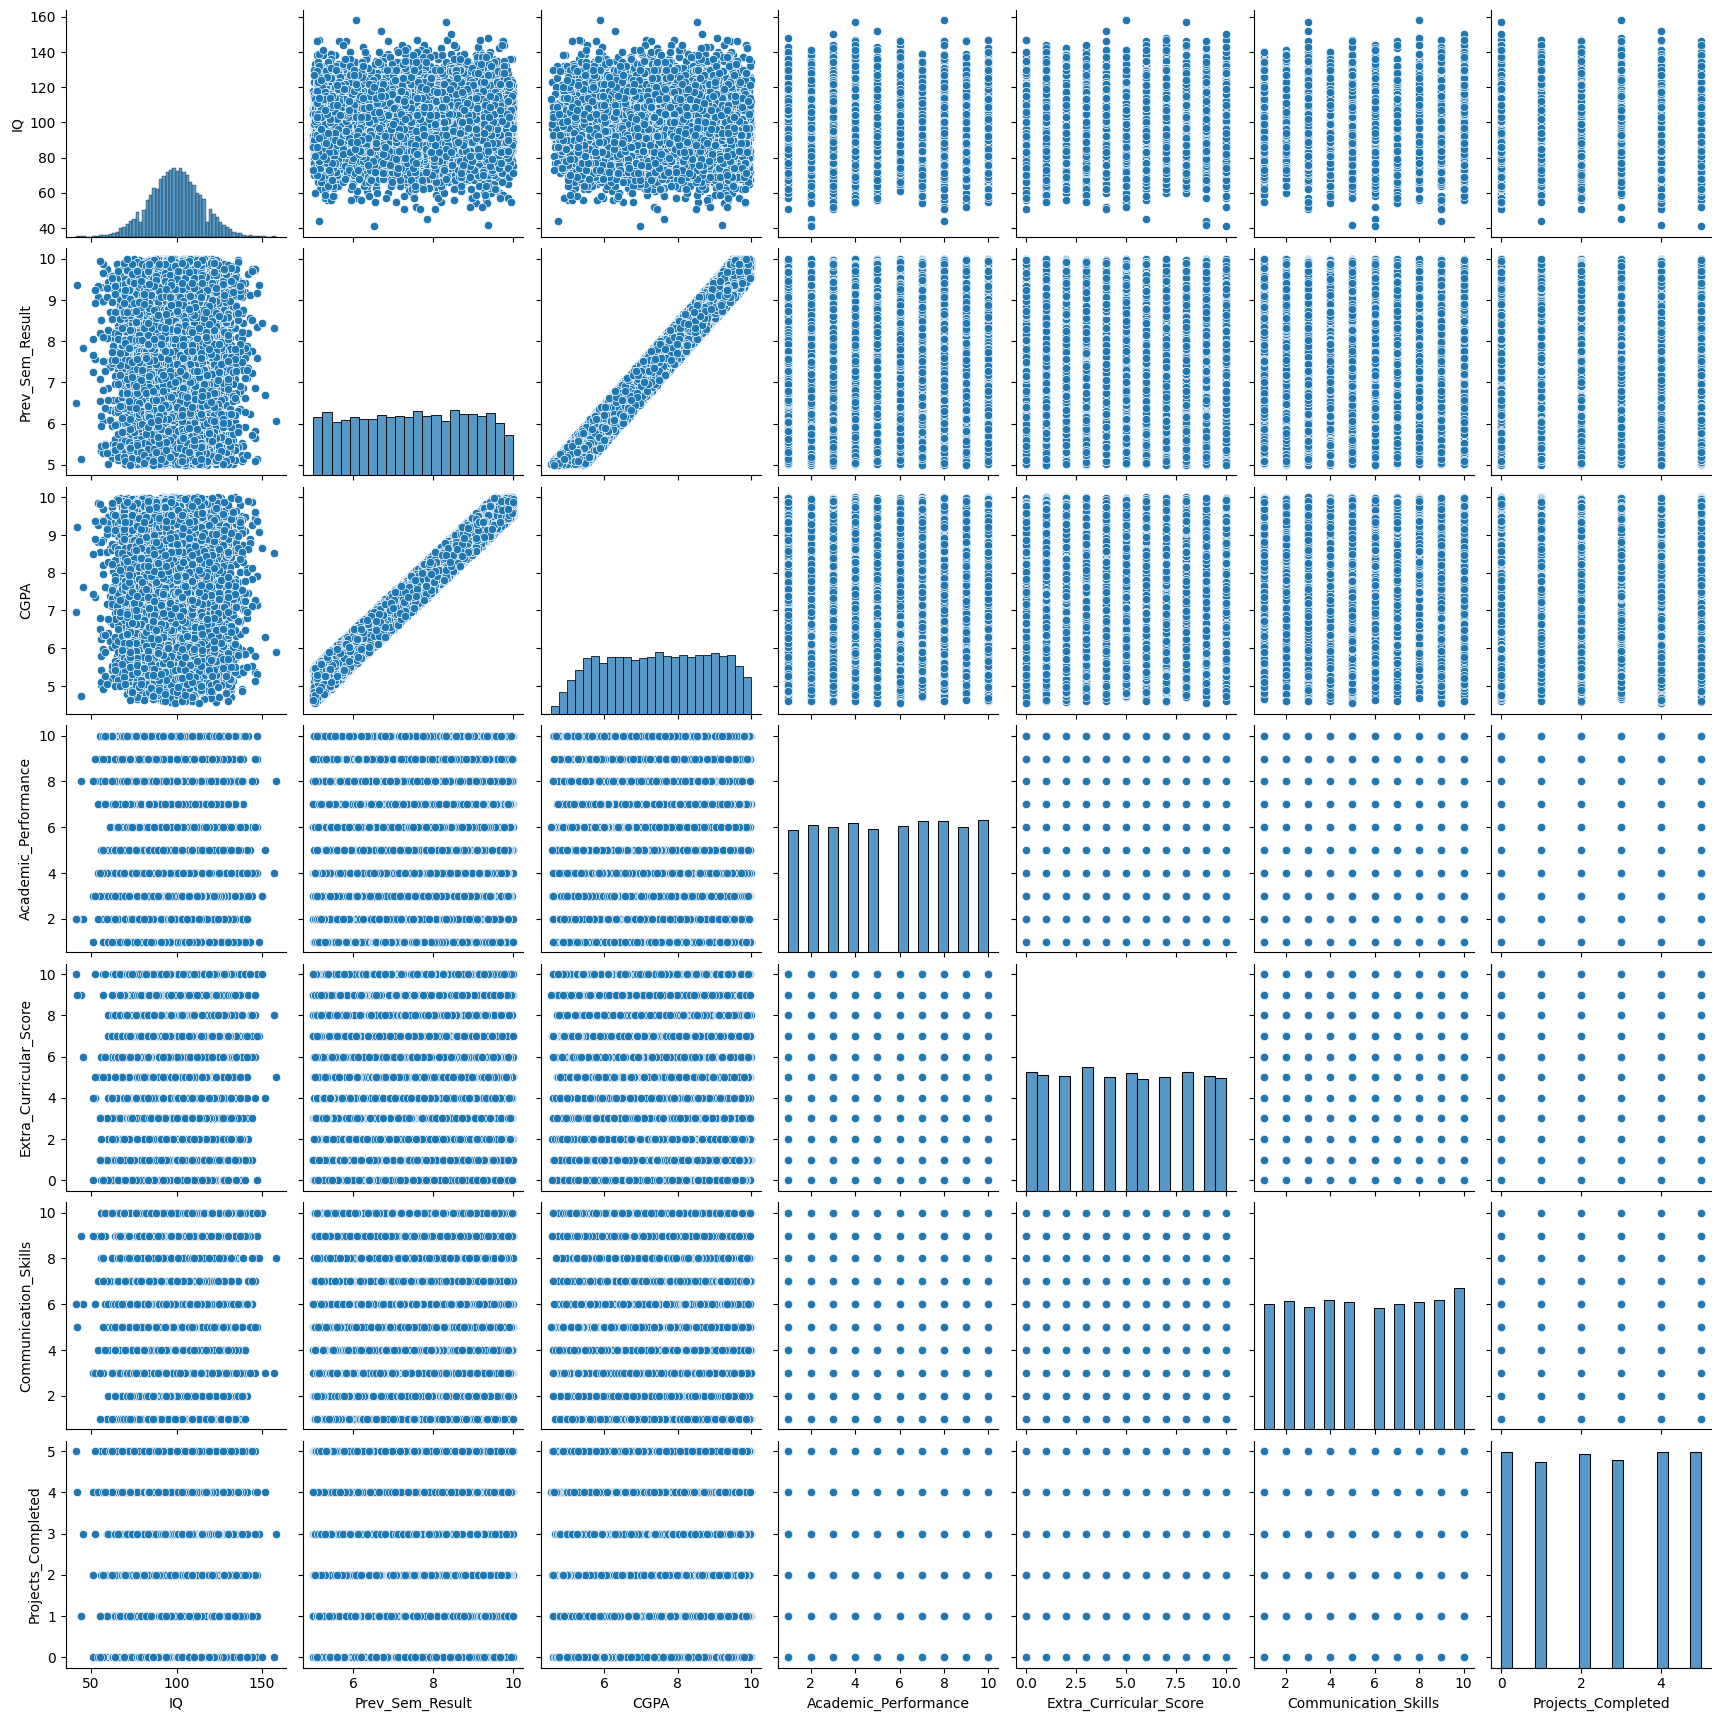

In [8]:
pairplot = sns.pairplot(df)
pairplot.savefig('../charts/pairplot.png')


In [9]:
placed_std = df[df['Placement'] =='Yes']
non_placed_std = df[df['Placement'] =='No']

In [10]:
non_placed_std

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,No,8,8,4,No
1,97,5.52,5.37,8,No,7,8,0,No
2,109,5.36,5.83,9,No,3,1,1,No
3,122,5.47,5.75,6,Yes,1,6,1,No
4,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...
9744,77,7.57,7.39,1,Yes,2,6,3,No
9747,70,9.25,9.34,7,No,0,7,2,No
9748,89,6.08,6.25,3,Yes,3,9,5,No
9749,107,8.77,8.92,3,No,7,5,1,No


In [11]:
from scipy.stats import chi2_contingency 

In [12]:
contingency = pd.crosstab(df['Internship_Experience'], df['Placement'])
chi2, p, dof, ex = chi2_contingency(contingency)
print(chi2, p)

0.8538525931724278 0.35546473760918174


In [13]:
from sklearn.feature_selection import f_classif

F, p = f_classif(df[df.select_dtypes('number').columns.tolist()], df['Placement'])
for f in [round(f,2) for f in F]: 
    print(f)

851.36
1086.61
1120.54
2.57
0.72
1108.91
470.41


In [14]:
col_numeric.columns

Index(['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed'],
      dtype='object')

In [15]:
print([round(f,2) for f in F])

[np.float64(851.36), np.float64(1086.61), np.float64(1120.54), np.float64(2.57), np.float64(0.72), np.float64(1108.91), np.float64(470.41)]


In [16]:
placement_encoded = df['Placement'].map({'Yes':1,"No":0})

In [17]:
from scipy.stats import pointbiserialr

for col in col_numeric.columns.tolist():

    corr, p_value = pointbiserialr(df[col], placement_encoded)
    
    print(f"'{col}' has this much correlation {round(corr,2)}")

'IQ' has this much correlation 0.28
'Prev_Sem_Result' has this much correlation 0.32
'CGPA' has this much correlation 0.32
'Academic_Performance' has this much correlation -0.02
'Extra_Curricular_Score' has this much correlation -0.01
'Communication_Skills' has this much correlation 0.32
'Projects_Completed' has this much correlation 0.21


C:\Users\HP\AppData\Local\Temp\ipykernel_25052\3907399025.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Placement', y='Communication_Skills', data=df, palette='Set2')


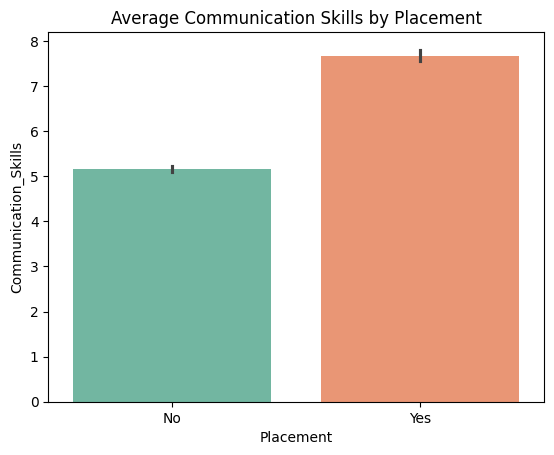

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Placement', y='Communication_Skills', data=df, palette='Set2')
plt.title("Average Communication Skills by Placement")
plt.savefig('../charts/communication_skills_by_placement.png')
plt.show()


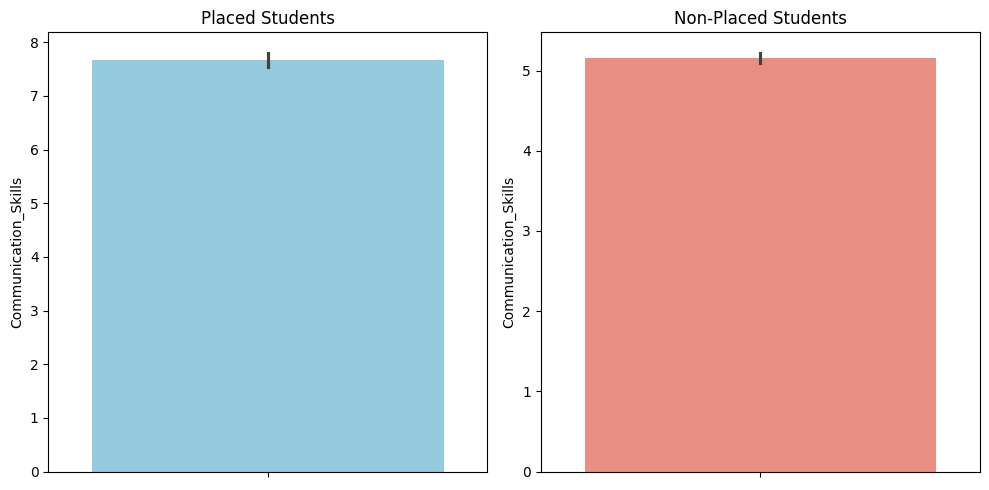

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

sns.barplot(y=placed_std['Communication_Skills'], ax=axes[0], color='skyblue')
axes[0].set_title("Placed Students")

sns.barplot(y=non_placed_std['Communication_Skills'], ax=axes[1], color='salmon')
axes[1].set_title("Non-Placed Students")

plt.tight_layout()
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_25052\1746565065.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Placement', y='Communication_Skills', data=df, palette='Set2');


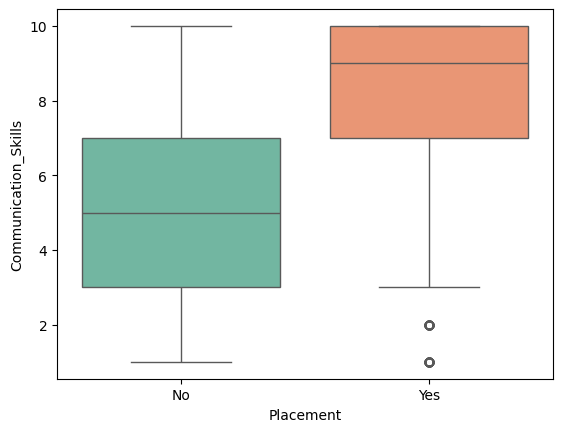

In [20]:
sns.boxplot(x='Placement', y='Communication_Skills', data=df, palette='Set2');
plt.savefig(f'../charts/communation_skill_by_placement_boxplot.png');
plt.show()


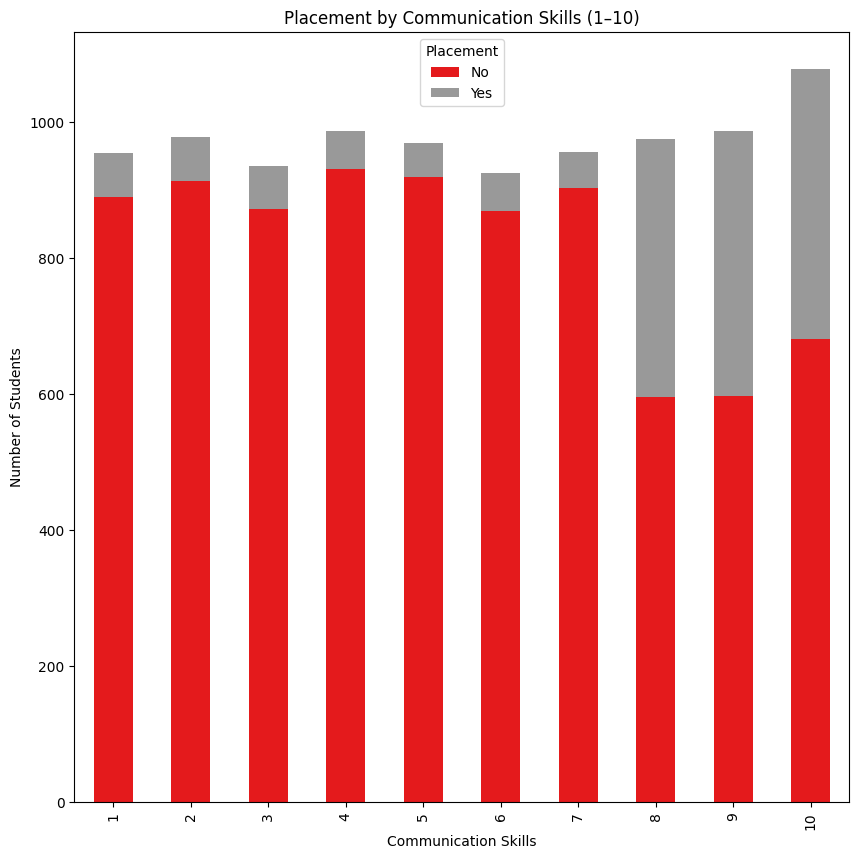

In [21]:
counts = df.groupby(['Communication_Skills', 'Placement']).size().unstack(fill_value=0)

counts.plot(kind='bar', stacked=True, figsize=(10,10), colormap='Set1')

plt.title("Placement by Communication Skills (1–10)")
plt.xlabel("Communication Skills")
plt.ylabel("Number of Students")
plt.legend(title="Placement", loc='upper center')
plt.savefig(f'communication_bar_chart_by_placement.png')
plt.show()
